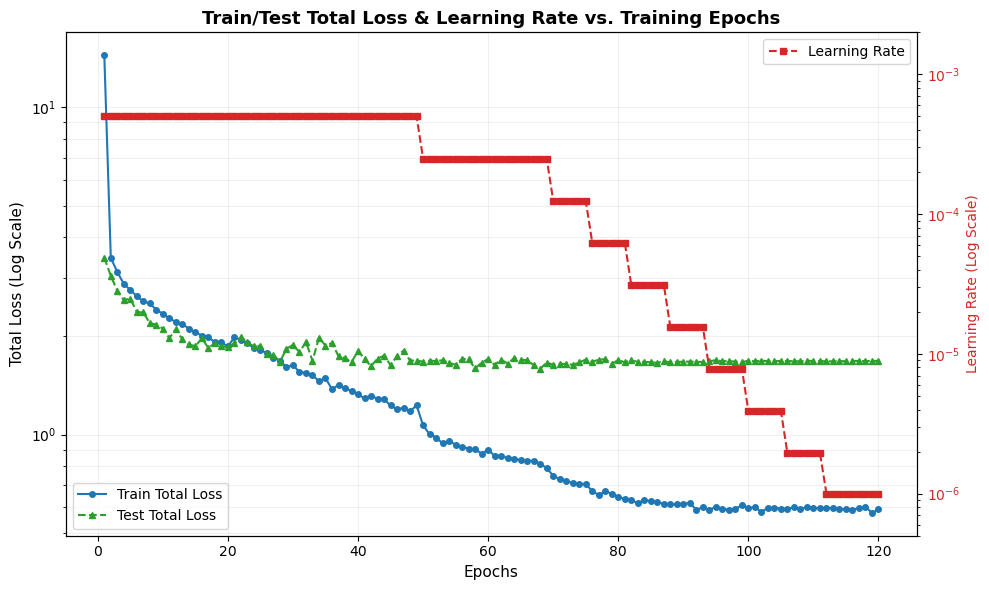

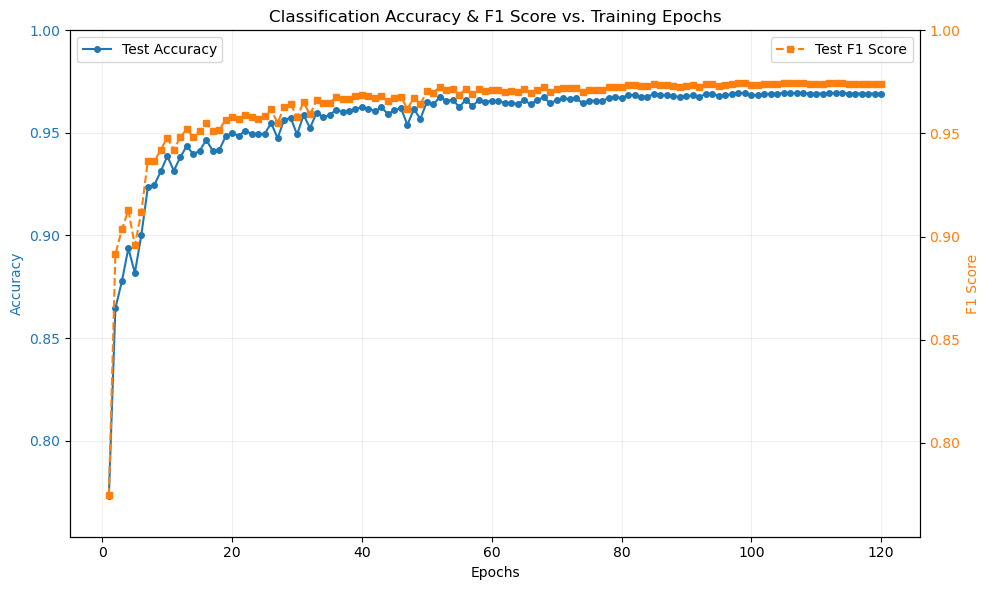

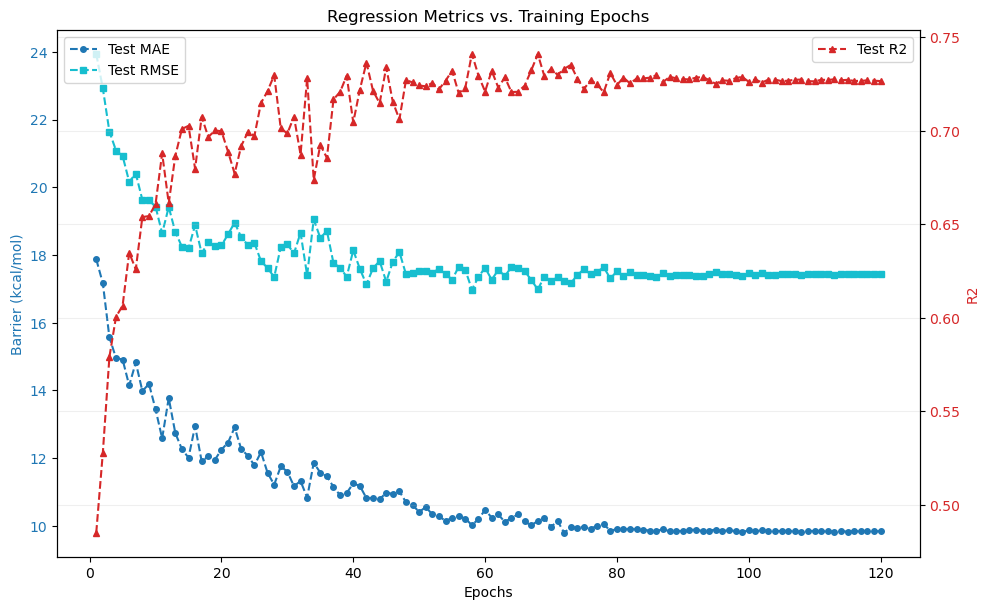

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt


# 日志文件路径（保持你的原始路径）
# log_file = './t1x_dim64_h8_n3_do0.2_w20_lrf0.8_lrp10_lr1e-3_ep200_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1762264378.0235028/log.json'
# log_file = './DFT/t1x_dim128_h8_n3_do0.2_w20_lrf0.7_lrp5_lr1e-3_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1763536170.2708519/log.json'
log_file = '/inspire/hdd/project/chemicalreaction/misixuan-CZXS24220243/qb/sii/MyWork/atomic_foundation/Uni-Reaction-Release/vote_run_1770283450/logs/fold_1/1770283456.6693184/log.json'

# 读取日志文件
with open(log_file, 'r') as f:
    log_data = json.load(f)

# 提取训练轮数
epochs = range(1, len(log_data['train_total_loss']) + 1)

# --------------------------
# 1. 总损失（左侧）+ 学习率（右侧）双y轴图
# --------------------------
# 训练集总损失
train_total_loss = log_data['train_total_loss']
# 学习率
train_lr = log_data['current_lr']
# 测试集总损失（从每轮test_metric中提取validation_loss→total_loss）
test_total_loss = []
for test_metric in log_data['test_metric']:
    # 从测试集指标中获取总损失（与eval_joint返回的validation_loss对应）
    test_total = test_metric['validation_loss']['total_loss']
    test_total_loss.append(test_total)

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：训练集+测试集总损失（共用对数刻度）
color_train = 'tab:blue'
color_test = 'tab:green'
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Total Loss (Log Scale)', fontsize=11)
# 训练集loss：蓝色实线+圆形标记
ax1.plot(epochs, train_total_loss, label='Train Total Loss', 
         marker='o', markersize=4, color=color_train, linewidth=1.5)
# 测试集loss：绿色虚线+三角形标记（区分训练集）
ax1.plot(epochs, test_total_loss, label='Test Total Loss', 
         marker='^', markersize=4, color=color_test, linewidth=1.5, linestyle='--')
ax1.set_yscale('log')  # 保留对数刻度，便于观察损失变化
ax1.tick_params(axis='y', labelcolor='black')  # 损失轴标签用黑色（两个曲线共用）
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, which="both", ls="-", alpha=0.2)

# 右侧y轴：学习率（对数刻度，适配指数衰减）
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Learning Rate (Log Scale)', color=color2)
ax2.plot(epochs, train_lr, label='Learning Rate', marker='s', markersize=4, color=color2, linestyle='--')
ax2.set_yscale('log')  # 学习率用对数刻度更清晰
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(5e-7, 2e-3)
ax2.legend(loc='upper right')

plt.title('Train/Test Total Loss & Learning Rate vs. Training Epochs', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# --------------------------
# 2. 分类准确率（左侧）+ F1分数（右侧）双y轴图
# --------------------------
# 提取测试集的ACC和F1（从classification指标中获取）
test_acc = [item['classification']['ACC'] for item in log_data['test_metric']]
test_f1 = [item['classification']['F1'] for item in log_data['test_metric']]  # 新增F1提取

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：分类准确率
color1 = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color=color1)
ax1.plot(epochs, test_acc, label='Test Accuracy', marker='o', markersize=4, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(max(0, min(test_acc) - 0.02), 1.0)  # 调整y轴范围，避免刻度太紧凑
ax1.legend(loc='upper left')
ax1.grid(True, ls="-", alpha=0.2)

# 右侧y轴：F1分数
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('F1 Score', color=color2)
ax2.plot(epochs, test_f1, label='Test F1 Score', marker='s', markersize=4, color=color2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(max(0, min(test_f1) - 0.02), 1.0)  # F1与ACC同范围（0-1）
ax2.legend(loc='upper right')

plt.title('Classification Accuracy & F1 Score vs. Training Epochs')
fig.tight_layout()
plt.show()

# --------------------------
# 3. 回归指标图（保持原始代码不变）
# --------------------------
# 提取测试集回归指标
test_mae = [item['regression']['MAE'] for item in log_data['test_metric']]
test_mse = [item['regression']['MSE'] for item in log_data['test_metric']]
test_rmse = [np.sqrt(mse) for mse in test_mse]  # 计算RMSE
test_r2 = [item['regression']['R2'] for item in log_data['test_metric']]

fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：MAE和RMSE
color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Barrier (kcal/mol)', color=color)
ax1.plot(epochs, test_mae, label='Test MAE', marker='o', markersize=4, linestyle='--', color='tab:blue')
ax1.plot(epochs, test_rmse, label='Test RMSE', marker='s', markersize=4, linestyle='--', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# 创建右侧y轴：R2
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('R2', color=color)  
ax2.plot(epochs, test_r2, label='Test R2', marker='^', markersize=4, linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  
plt.title('Regression Metrics vs. Training Epochs')
plt.grid(True, ls="-", alpha=0.2)
plt.show()

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.metrics import roc_curve, auc, confusion_matrix

# --------------------------
# 配置参数（根据实际路径修改）
# --------------------------
json_file = '/inspire/hdd/project/chemicalreaction/misixuan-CZXS24220243/qb/sii/MyWork/atomic_foundation/Uni-Reaction-Release/vote_run_1770283450/ensemble_result.json'

# --------------------------
# 1. 读取并解析JSON数据
# --------------------------
with open(json_file, 'r') as f:
    data = json.load(f)

# 提取核心数据
reg_true_raw = data['regression']['true_values']
reg_pred_raw = data['regression']['pred_values']
cls_true_raw = data['classification']['true_labels']
cls_pred_raw = data['classification']['pred_labels']
cls_metrics = data['classification']['metrics']
reg_metrics = data['regression']['metrics']

# 读取正类预测得分（计算阈值必需）
try:
    cls_scores_raw = data['classification']['cls_scores']  # 正类的logits/概率
except KeyError:
    raise ValueError("计算阈值需要正类预测得分！请修改eval_joint函数，添加'cls_scores'（正类logits或概率）")

# --------------------------
# 2. 数据预处理（过滤无效值）
# --------------------------
# 回归数据预处理
reg_true = []
reg_pred = []
cls_pred = []
for t_reg, p_reg, t_cls, p_cls in zip(reg_true_raw, reg_pred_raw, cls_true_raw, cls_pred_raw):
    if isinstance(t_reg, (int, float)) and isinstance(p_reg, (int, float)):
        if not (math.isnan(t_reg) or math.isnan(p_reg)):
            reg_true.append(t_reg)
            reg_pred.append(p_reg)
            cls_pred.append(p_cls)

# 分类&阈值计算数据预处理（仅保留有效标签和得分）
valid_data = []
for t_cls, p_cls, score_cls in zip(cls_true_raw, cls_pred_raw, cls_scores_raw):
    if (isinstance(t_cls, (int, float)) and isinstance(score_cls, (int, float)) and
        t_cls in [0, 1] and p_cls in [0, 1]):
        valid_data.append((t_cls, p_cls, score_cls))

cls_true_auc = [x[0] for x in valid_data]
cls_scores_auc = [x[2] for x in valid_data]
cls_pred_valid = [x[1] for x in valid_data]
cls_scores_valid = [x[2] for x in valid_data]

# --------------------------
# 3. 关键计算（含阈值分析）
# --------------------------
# 回归数据范围
if reg_true and reg_pred:
    min_val = min(min(reg_true), min(reg_pred))
    max_val = max(max(reg_true), max(reg_pred))
    val_range = max_val - min_val
    min_plot = min_val - 0.01 * val_range
    max_plot = max_val + 0.01 * val_range
else:
    min_plot, max_plot = 0, 1

# 分类指标
acc = cls_metrics['ACC']
f1 = cls_metrics['F1']
mae = reg_metrics['MAE']
r2 = reg_metrics['R2']

# --------------------------
# 核心：计算分类阈值（重点）
# --------------------------
# 3.1 计算最优阈值（基于Youden指数：TPR - FPR 最大化）
fpr, tpr, thresholds = roc_curve(cls_true_auc, cls_scores_auc, pos_label=1)
roc_auc = auc(fpr, tpr)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]  # 最优阈值
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# # 3.2 推断模型实际使用的阈值（从预测标签反推）
# # 逻辑：预测为1的最小得分 ≈ 实际阈值（允许微小误差）
# score_1 = [s for p, s in zip(cls_pred_valid, cls_scores_valid) if p == 1]  # 预测1的得分
# score_0 = [s for p, s in zip(cls_pred_valid, cls_scores_valid) if p == 0]  # 预测0的得分
# actual_threshold = None
# if score_1 and score_0:
#     min_score_1 = min(score_1)
#     max_score_0 = max(score_0)
#     if min_score_1 >= max_score_0:
#         actual_threshold = (min_score_1 + max_score_0) / 2  # 取中间值作为实际阈值
#     else:
#         # 存在得分交叉（可能是噪声），用最优阈值替代参考
#         actual_threshold = optimal_threshold
#         print(f"⚠️ 预测得分存在交叉，实际阈值参考最优阈值：{actual_threshold:.4f}")
# elif score_1:
#     actual_threshold = min(score_1) - 0.01  # 预测全为1，阈值略低于最小得分
# elif score_0:
#     actual_threshold = max(score_0) + 0.01  # 预测全为0，阈值略高于最大得分

# 输出阈值结果
print("="*50)
print("📊 分类阈值分析结果")
print(f"最优阈值（Youden指数最大化）：{optimal_threshold:.4f}")
print(f"对应性能：TPR={optimal_tpr:.4f}, FPR={optimal_fpr:.4f}")
# print(f"模型实际使用的阈值（反推）：{actual_threshold:.4f}")
# print(f"默认阈值（常见参考）：0.5")
print("="*50)

# --------------------------
# 4. 绘图（一行三列，ROC图标注阈值）
# --------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 子图1：分类预测=0的回归散点图
reg_true_0 = [t for t, p in zip(reg_true, cls_pred) if p == 0]
reg_pred_0 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 0]
ax1.scatter(reg_true_0, reg_pred_0, color='tab:blue', alpha=0.6,
            label=f'Pred=0 (Count: {len(reg_true_0)})', s=50, edgecolors='white', linewidth=0.5)
ax1.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
ax1.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax1.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax1.set_title('Regression: Classification Prediction = 0', fontsize=12, fontweight='bold')
ax1.set_xlim(min_plot, max_plot)
ax1.set_ylim(min_plot, max_plot)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# 子图2：分类预测=1的回归散点图
reg_true_1 = [t for t, p in zip(reg_true, cls_pred) if p == 1]
reg_pred_1 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 1]
ax2.scatter(reg_true_1, reg_pred_1, color='tab:red', alpha=0.6,
            label=f'Pred=1 (Count: {len(reg_true_1)})', s=50, edgecolors='white', linewidth=0.5)
ax2.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
ax2.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax2.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax2.set_title('Regression: Classification Prediction = 1', fontsize=12, fontweight='bold')
ax2.set_xlim(min_plot, max_plot)
ax2.set_ylim(min_plot, max_plot)
ax2.set_aspect('equal', adjustable='box')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# 子图3：ROC图（标注最优阈值）
ax3.plot(fpr, tpr, color='tab:green', lw=2, alpha=0.8, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Guess (AUC = 0.5)')
# 标注最优阈值点（红色圆点）
ax3.scatter(optimal_fpr, optimal_tpr, color='red', s=80, alpha=0.8, 
            label=f'Optimal Threshold = {optimal_threshold:.4f}')
# 标注实际阈值对应的点（蓝色三角）
# if actual_threshold is not None:
#     # 计算实际阈值对应的FPR和TPR
#     actual_pred = (np.array(cls_scores_auc) >= actual_threshold).astype(int)
#     cm = confusion_matrix(cls_true_auc, actual_pred)
#     if cm.shape == (2, 2):
#         tn, fp, fn, tp = cm.ravel()
#         actual_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
#         actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
#         ax3.scatter(actual_fpr, actual_tpr, color='blue', s=80, marker='^', alpha=0.8,
#                     label=f'Actual Threshold = {actual_threshold:.4f}')

ax3.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax3.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax3.set_title('Classification ROC Curve & Thresholds', fontsize=12, fontweight='bold')
ax3.set_xlim([-0.01, 1.01])
ax3.set_ylim([-0.01, 1.01])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--')

# 总标题（包含阈值信息）
fig.suptitle(
    f'Joint Model Prediction Results\n'
    f'Classification: ACC={acc:.4f}, F1={f1:.4f} | '
    f'Regression: MAE={mae:.2f}, R2={r2:.4f} | '
    f'ROC AUC={roc_auc:.4f}\n'
    f'Optimal Threshold={optimal_threshold:.4f}, TPR={optimal_tpr:.4f}, FPR={optimal_fpr:.4f}, FNR={1-optimal_tpr:.4f}',
    # f'Optimal Threshold={optimal_threshold:.4f}, Actual Threshold={actual_threshold:.4f}',
    fontsize=14, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 预留更多空间显示总标题
plt.show()

# 保存高清图片
# fig.savefig('./prediction_results_with_thresholds.png', dpi=300, bbox_inches='tight')
# print("图表已保存，包含阈值标注！")

KeyError: 'true_values'

vote_model

/root/miniforge3/envs/RAlign/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


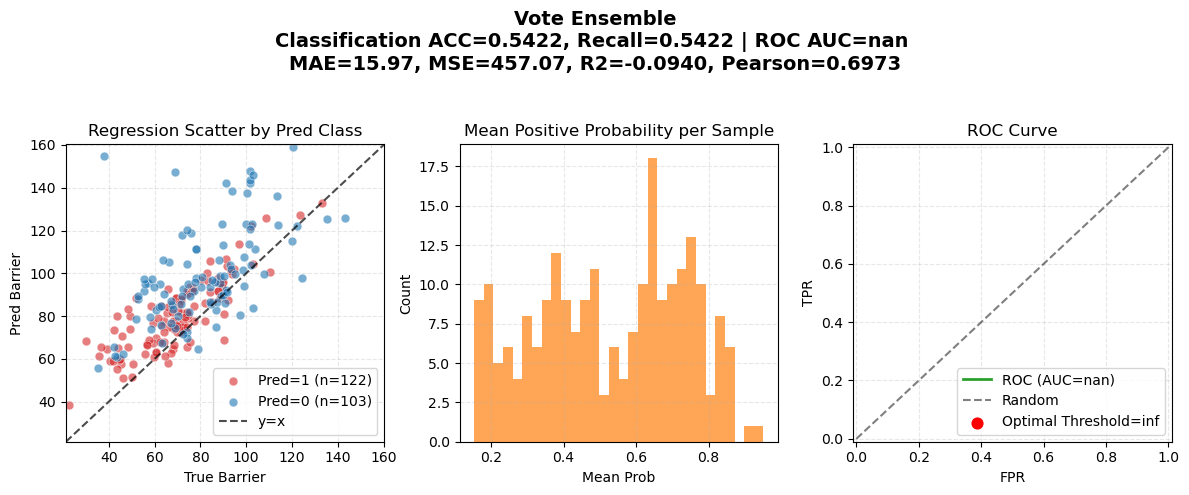

In [3]:
# INP = "./vote_run_1765811890_dim128_layer3/ensemble_result.json"
# OUT = "./vote_run_1765811890_dim128_layer3"
# INP = "./vote_run_1765811890_dim128_local4/YARP_OOD.json"
# OUT = "./vote_run_1765811890_dim128_local4"
# INP = "./vote_run_1765876718_dim64_local4/YARP_OOD.json"
# OUT = "./vote_run_1765876718_dim64_local4/"
# INP = "./vote_run_1765876723_dim32_local4/YARP_OOD.json"
# OUT = "./vote_run_1765876723_dim32_local4/"
# INP = "./vote_run_1765877287_dim128_local0/YARP_OOD.json"
# OUT = "./vote_run_1765877287_dim128_local0/"
# INP = "./vote_run_176589172_dim64_local0/YARP_OOD.json"
# OUT = "./vote_run_176589172_dim64_local0/"
INP = "./vote_run_1765891836_dim32_local0/YARP_OOD.json"
OUT = "./vote_run_1765891836_dim32_local0/"

import argparse
import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_fscore_support, r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

def load_data(path):
    with open(path, 'r') as f:
        data = json.load(f)
    cls_true = np.array(data['classification']['true'])
    cls_pred = np.array(data['classification']['pred'])
    cls_mean_prob = np.array(data['classification'].get('mean_prob', []))
    reg_true = np.array(data['regression']['true'])
    reg_pred = np.array(data['regression']['pred'])
    return cls_true, cls_pred, cls_mean_prob, reg_true, reg_pred


# parser = argparse.ArgumentParser("可视化投票集成结果（JSON）")
# # parser.add_argument('--json', required=True, help='run_vote_predict 生成的 ensemble_result.json')
# # parser.add_argument('--save', type=str, default=None, help='可选，保存图片路径（默认为显示）')
# parser.add_argument('--json', default="sii/MyWork/atomic_foundation/Uni-Reaction-Release/vote_run_1765811890/ensemble_result.json", help='run_vote_predict 生成的 ensemble_result.json')
# parser.add_argument('--save', default="sii/MyWork/atomic_foundation/Uni-Reaction-Release/vote_run_1765811890/", help='可选，保存图片路径（默认为显示）')
# args = parser.parse_args()

# cls_true, cls_pred, cls_mean_prob, reg_true, reg_pred = load_data(args.json)
cls_true, cls_pred, cls_mean_prob, reg_true, reg_pred = load_data(INP)

# 过滤回归 NaN
reg_mask = np.isfinite(reg_true) & np.isfinite(reg_pred)
reg_true_valid = reg_true[reg_mask]
reg_pred_valid = reg_pred[reg_mask]

# 分类指标
acc = float(np.mean(cls_true == cls_pred)) if cls_true.size else float('nan')
cls_prec, cls_rec, cls_f1, _ = precision_recall_fscore_support(
    cls_true, cls_pred, average='binary', pos_label=1, zero_division=0
) if cls_true.size else (float('nan'),) * 3

# 回归指标
if reg_true_valid.size:
    mae = float(mean_absolute_error(reg_true_valid, reg_pred_valid))
    mse = float(mean_squared_error(reg_true_valid, reg_pred_valid))
    var = np.var(reg_true_valid)
    r2 = float(r2_score(reg_true_valid, reg_pred_valid)) if var > 0 else float('nan')
    
    # ========== 新增：皮尔逊相关系数计算 ==========
    # 计算前提：样本量至少为2（否则无法计算相关系数）
    if len(reg_true_valid) >= 2:
        try:
            # pearsonr返回 (相关系数, p值)，我们只取相关系数
            pearson_corr, _ = pearsonr(reg_true_valid, reg_pred_valid)
            pearson_corr = float(pearson_corr)  # 统一转为float类型
        except:
            # 异常情况（如所有值相同导致标准差为0），设为nan
            pearson_corr = float('nan')
    else:
        # 样本量不足2，无法计算相关系数
        pearson_corr = float('nan')
else:
    mae = mse = r2 = float('nan')

# ROC
if cls_mean_prob.size:
    fpr, tpr, thresholds = roc_curve(cls_true, cls_mean_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    youden = tpr - fpr
    opt_idx = np.argmax(youden)
    opt_thresh = thresholds[opt_idx]
    opt_fpr, opt_tpr = fpr[opt_idx], tpr[opt_idx]
else:
    fpr = tpr = thresholds = np.array([])
    roc_auc = opt_thresh = opt_fpr = opt_tpr = float('nan')

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# 回归散点（按分类预测分开）
if reg_true_valid.size:
    cls_pred_valid = cls_pred[reg_mask]
    for cls_val, color in [(1, 'tab:red'), (0, 'tab:blue')]:
        idx = cls_pred_valid == cls_val
        axes[0].scatter(
            reg_true_valid[idx], reg_pred_valid[idx],
            color=color, alpha=0.6, s=40, edgecolors='white', linewidth=0.5,
            label=f'Pred={cls_val} (n={idx.sum()})'
        )
    min_val = float(min(reg_true_valid.min(), reg_pred_valid.min()))
    max_val = float(max(reg_true_valid.max(), reg_pred_valid.max()))
    vr = max_val - min_val
    lo, hi = min_val - 0.01 * vr, max_val + 0.01 * vr
    axes[0].plot([lo, hi], [lo, hi], 'k--', alpha=0.7, label='y=x')
    axes[0].set_xlim(lo, hi)
    axes[0].set_ylim(lo, hi)
axes[0].set_title('Regression Scatter by Pred Class')
axes[0].set_xlabel('True Barrier')
axes[0].set_ylabel('Pred Barrier')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# 直方图：分类平均概率
if cls_mean_prob.size:
    axes[1].hist(cls_mean_prob, bins=30, color='tab:orange', alpha=0.7)
    axes[1].set_title('Mean Positive Probability per Sample')
    axes[1].set_xlabel('Mean Prob')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No prob data', ha='center')
axes[1].grid(alpha=0.3, linestyle='--')

# ROC
if cls_mean_prob.size:
    axes[2].plot(fpr, tpr, lw=2, color='tab:green', label=f'ROC (AUC={roc_auc:.4f})')
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    axes[2].scatter(opt_fpr, opt_tpr, color='red', s=60, label=f'Optimal Threshold={opt_thresh:.4f}')
    axes[2].set_xlim([-0.01, 1.01])
    axes[2].set_ylim([-0.01, 1.01])
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.3, linestyle='--')

fig.suptitle(
    f"Vote Ensemble\nClassification ACC={acc:.4f}, Recall={cls_rec:.4f} | ROC AUC={roc_auc:.4f} \n"
    f"MAE={mae:.2f}, MSE={mse:.2f}, R2={r2:.4f}, Pearson={pearson_corr:.4f}",
    fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# if args.save:
# if True:
#     out_dir = os.path.dirname(OUT)
#     if out_dir and not os.path.exists(out_dir):
#         os.makedirs(out_dir, exist_ok=True)
#     plt.savefig(OUT, dpi=300, bbox_inches='tight')
#     # print(f"[INFO] 图已保存: {args.save}")
# else:
plt.show()


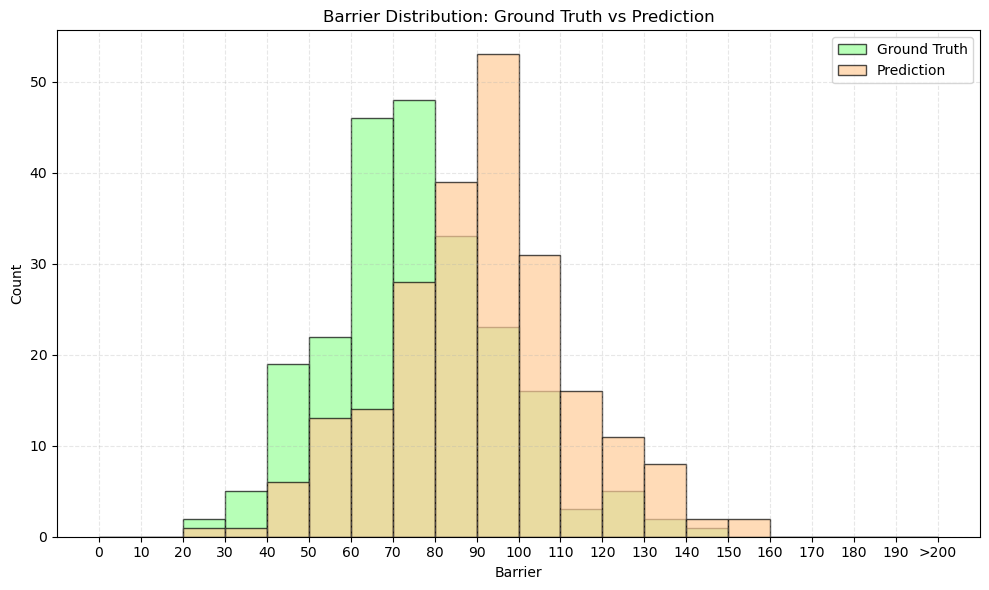

In [11]:
import argparse
import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np


def load_from_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    reg_true = np.array(data['regression']['true'])
    reg_pred = np.array(data['regression']['pred'])
    cls_true = np.array(data['classification']['true'])
    cls_pred = np.array(data['classification']['pred'])
    mean_prob = np.array(data['classification'].get('mean_prob', []))
    return reg_true, reg_pred, cls_true, cls_pred, mean_prob


def plot_distributions(reg_true, reg_pred, save=None):
    # 过滤有效值
    reg_true_valid = reg_true[np.isfinite(reg_true)]
    reg_pred_valid = reg_pred[np.isfinite(reg_pred)]

    plt.figure(figsize=(10, 6))
    # 参照示例：0-200 分段，>200 归为最后一档
    bin_width = 10
    bins = np.arange(0, 201, bin_width)  # 0,10,...,200；200 代表 >=200
    # 超过 200 的截到 200
    reg_true_cap = np.where(reg_true_valid > 200, 200, reg_true_valid)
    reg_pred_cap = np.where(reg_pred_valid > 200, 200, reg_pred_valid)
    #hist_colors = ["#99ff99", "#ffcc99", "#c2c2f0"]
    plt.hist(reg_true_valid, bins=bins, alpha=0.7, color="#99ff99", edgecolor="black", label='Ground Truth')
    plt.hist(reg_pred_valid, bins=bins, alpha=0.7, color="#ffcc99", edgecolor="black", label='Prediction')
    plt.xlabel('Barrier')
    plt.ylabel('Count')
    plt.title('Barrier Distribution: Ground Truth vs Prediction')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')
    # 自定义刻度：0-200，最后一个刻度显示 >200
    tick_positions = bins
    tick_labels = [f"{int(x)}" for x in tick_positions]
    if tick_labels:
        tick_labels[-1] = ">200"
    plt.xticks(tick_positions, tick_labels, rotation=0)

    plt.tight_layout()
    if save:
        out_dir = os.path.dirname(save)
        if out_dir and not os.path.exists(out_dir):
            os.makedirs(out_dir, exist_ok=True)
        plt.savefig(save, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图已保存到 {save}")
    else:
        plt.show()


def main():
    # parser = argparse.ArgumentParser("可视化能垒分布（真实 vs 预测）")
    # parser.add_argument('--json', required=True, help='run_vote_predict 生成的 ensemble_result.json')
    # parser.add_argument('--save', type=str, default=None, help='保存路径（不传则直接展示）')
    # args = parser.parse_args()

    # reg_true, reg_pred, cls_true, cls_pred, mean_prob = load_from_json(args.json)
    reg_true, reg_pred, cls_true, cls_pred, mean_prob = load_from_json(INP)
    if reg_true.size == 0 or reg_pred.size == 0:
        print("缺少回归数据，无法绘制分布。")
        return

    # plot_distributions(reg_true, reg_pred, save=args.save)
    # plot_distributions(reg_true, reg_pred, save=OUT)
    plot_distributions(reg_true, reg_pred)


if __name__ == '__main__':
    main()


In [15]:
BAIS = 18
for BAIS in range(150, 170):
    BAIS /= 10
    # print(float(r2_score(reg_true_valid, reg_pred_valid)) if var > 0 else float('nan'))
    print(BAIS, float(r2_score(reg_true_valid, reg_pred_valid - BAIS)) if var > 0 else float('nan'))

15.0 0.4841429391979998
15.1 0.48472434308177315
15.2 0.48525787533794007
15.3 0.48574353596650033
15.4 0.48618132496745414
15.5 0.4865712423408012
15.6 0.4869132880865418
15.7 0.4872074622046758
15.8 0.4874537646952033
15.9 0.4876521955581242
16.0 0.4878027547934385
16.1 0.4879054424011463
16.2 0.48796025838124746
16.3 0.48796720273374206
16.4 0.4879262754586301
16.5 0.4878374765559117
16.6 0.48770080602558663
16.7 0.487516263867655
16.8 0.4872838500821167
16.9 0.4870035646689721
